# Creating web maps with smart mapping
Notebook demonstrating various capabilities of the new web map API

In [1]:
from arcgis.gis import *
from arcgis.mapping import WebMap
from arcgis.raster import apply
from arcgis.features import FeatureLayer
from arcgis.geocoding import geocode
from arcgis.features import Feature, FeatureSet, FeatureCollection
from arcgis.mapping import MapImageLayer
import json
from arcgis.geometry import Point, Polyline, Polygon, Envelope

In [2]:
gis = GIS("https://www.arcgis.com","arcgis_python", "amazing_arcgis_123")

Some regular layers

<Item title:"Kindness" type:Feature Layer Collection owner:Community_Geography>
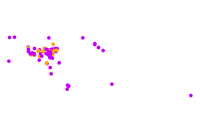

In [3]:
point_flc_item = gis.content.get('415cda28e2614f1d82cb5822bf3c5c3d')
# point_flc_item = gis.content.get('f482f5c329984eac9a524024f9737607')
point_flc_item

<Item title:"Census Blocks 2010 (with 2017 and 2022 Data)" type:Feature Layer Collection owner:JohnsCreekGA>
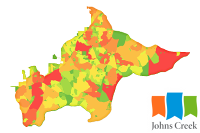

In [4]:
flc_item = gis.content.get('8d29d4a521f34ebba40dd918ac8322c3')
flc_item

In [5]:
for f in flc_item.layers[0].properties.fields:
    print(f['name'])

OBJECTID
STATEFP10
COUNTYFP10
TRACTCE10
BLOCKCE10
GEOID10
NAME10
MTFCC10
UR10
UACE10
FUNCSTAT10
ALAND10
AWATER10
INTPTLAT10
INTPTLON10
Shape__Area
Shape__Length
ID
sourceCountry
ENRICH_FID
aggregationMethod
HasData
TOTPOP_CY
TOTPOP_FY
POP0_CY
POP5_CY
POP10_CY
POP15_CY
POP20_CY
POP25_CY
POP30_CY
POP35_CY
POP40_CY
POP45_CY
POP50_CY
POP55_CY
POP60_CY
POP65_CY
POP70_CY
POP75_CY
POP80_CY
POP85_CY
POP18UP_CY
MEDAGE_CY
MALES_CY
MEDMAGE_CY
FEMALES_CY
MEDFAGE_CY
POP0_FY
POP5_FY
POP10_FY
POP15_FY
POP20_FY
POP25_FY
POP30_FY
POP35_FY
POP40_FY
POP45_FY
POP50_FY
POP55_FY
POP60_FY
POP65_FY
POP70_FY
POP75_FY
POP80_FY
POP85_FY
POP18UP_FY
MEDAGE_FY
MALES_FY
MEDMAGE_FY
FEMALES_FY
MEDFAGE_FY
MEDHINC_CY
MEDHINC_FY
MEDVAL_CY
MEDVAL_FY
WHITE_CY
BLACK_CY
ASIAN_CY
OTHRACE_CY
HISPPOP_CY
WHITE_FY
BLACK_FY
ASIAN_FY
OTHRACE_FY
HISPPOP_FY
SHAPE__Area_2
SHAPE__Length_2


<Item title:"GAWeatherStations" type:Map Image Layer owner:rbagby_gema>
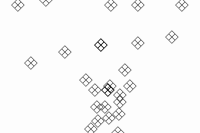

In [6]:
mil_item = gis.content.get('c6719c88770f402690c0ca25afe8c405')
mil_item

In [7]:
mil = MapImageLayer("https://sampleserver6.arcgisonline.com/arcgis/rest/services/Census/MapServer")
mil

<MapImageLayer url:"https://sampleserver6.arcgisonline.com/arcgis/rest/services/Census/MapServer">

## Heat map renderer

In [11]:
hm_map = gis.map("Georgia")
hm_map

In [12]:
hm_map.add_layer(point_flc_item, {'renderer':'HeatmapRenderer'})

In [10]:
hm_map._smartmapping_layer_list

[]

In [10]:
json.loads(hm_map._js_layer_list)[0]['renderer']

{'blurRadius': 10,
 'colorStops': [{'color': [255, 140, 0, 0], 'ratio': 0},
  {'color': [255, 140, 0, 255], 'ratio': 0.75},
  {'color': [255, 0, 0, 255], 'ratio': 0.9}],
 'field': None,
 'maxPixelIntensity': 100,
 'minPixelIntensity': 0,
 'type': 'heatmap'}

In [11]:
hm_map._process_smart_mapping()

In [12]:
hm_map._webmap.layers

[{
   "layerDefinition": {
     "drawingInfo": {
       "renderer": {
         "colorStops": [
           {
             "ratio": 0,
             "color": [
               255,
               140,
               0,
               0
             ]
           },
           {
             "ratio": 0.75,
             "color": [
               255,
               140,
               0,
               255
             ]
           },
           {
             "ratio": 0.9,
             "color": [
               255,
               0,
               0,
               255
             ]
           }
         ],
         "maxPixelIntensity": 100,
         "field": null,
         "blurRadius": 10,
         "type": "heatmap",
         "minPixelIntensity": 0
       }
     }
   },
   "layerType": "ArcGISFeatureLayer",
   "title": "Map Acts of Kindness",
   "url": "https://services1.arcgis.com/7Csm4eKNP8xsiEc1/arcgis/rest/services/Kindness/FeatureServer/0",
   "visibility": true,
   "opacity": 1,
  

### Save the web map with heatmap

In [13]:
wm_item1 = hm_map.save("GA WM with heatmap3", "Created using Notebooks", ['automation', 'science'])
wm_item1

<Item title:"GA WM with heatmap3" type:Web Map owner:arcgis_python>

In [14]:
wm = WebMap(wm_item1)
wm

## ClassedColorRenderer

In [5]:
cc_map = gis.map("Duluth, GA")
cc_map

In [6]:
cc_map.add_layer(point_flc_item)

In [13]:
cc_map.layers

[<FeatureLayer url:"https://services1.arcgis.com/7Csm4eKNP8xsiEc1/arcgis/rest/services/Kindness/FeatureServer/0">]

In [9]:
json.loads(cc_map._js_layer_list)[1]['renderer'].keys()

dict_keys(['type', 'field', 'defaultSymbol', 'minValue', 'classBreakInfos', 'defaultLabel', 'classificationMethod'])

In [10]:
json.loads(cc_map._js_layer_list)[1]['renderer']['type']

'classBreaks'

In [11]:
json.loads(cc_map._js_layer_list)[1]['renderer']['field']

'POP20_CY'

In [12]:
json.loads(cc_map._js_layer_list)[1]['renderer']['defaultSymbol']

{'color': [170, 170, 170, 255],
 'outline': {'color': [153, 153, 153, 255],
  'style': 'esriSLSSolid',
  'type': 'esriSLS',
  'width': 0.375},
 'style': 'esriSFSSolid',
 'type': 'esriSFS'}

In [13]:
json.loads(cc_map._js_layer_list)[1]['renderer']['minValue']

0

In [14]:
json.loads(cc_map._js_layer_list)[1]['renderer']['defaultLabel']

'Other'

In [15]:
json.loads(cc_map._js_layer_list)[1]['renderer']['classificationMethod']

'esriClassifyQuantile'

In [16]:
json.loads(cc_map._js_layer_list)[1]['renderer']['classBreakInfos']

[{'classMaxValue': 0,
  'label': '0 to 0',
  'symbol': {'color': [230, 238, 207, 255],
   'outline': {'color': [153, 153, 153, 255],
    'style': 'esriSLSSolid',
    'type': 'esriSLS',
    'width': 0.375},
   'style': 'esriSFSSolid',
   'type': 'esriSFS'}},
 {'classMaxValue': 2,
  'label': '> 0 to 2',
  'symbol': {'color': [155, 196, 193, 255],
   'outline': {'color': [153, 153, 153, 255],
    'style': 'esriSLSSolid',
    'type': 'esriSLS',
    'width': 0.375},
   'style': 'esriSFSSolid',
   'type': 'esriSFS'}},
 {'classMaxValue': 6,
  'label': '> 2 to 6',
  'symbol': {'color': [105, 168, 183, 255],
   'outline': {'color': [153, 153, 153, 255],
    'style': 'esriSLSSolid',
    'type': 'esriSLS',
    'width': 0.375},
   'style': 'esriSFSSolid',
   'type': 'esriSFS'}},
 {'classMaxValue': 15,
  'label': '> 6 to 15',
  'symbol': {'color': [75, 126, 152, 255],
   'outline': {'color': [153, 153, 153, 255],
    'style': 'esriSLSSolid',
    'type': 'esriSLS',
    'width': 0.375},
   'style': '

In [7]:
cc_map.add_layer(flc_item,{'renderer':'ClassedColorRenderer','field_name':'POP20_CY'})

### Save as web map - with CCR

In [8]:
ccwm = cc_map.save("WM with CCR - NB", "Web map with ClassedColorRenderer", ['Automation'])
ccwm

<Item title:"WM with CCR - NB" type:Web Map owner:arcgis_python>

In [9]:
wm = WebMap(ccwm)
wm

## ClassedSizeRenderer

In [19]:
cs_map = gis.map("Duluth, GA", zoomlevel=8)
cs_map

In [14]:
cs_map.add_layer(point_flc_item)

In [15]:
cs_map.add_layer(flc_item, {'renderer':'ClassedSizeRenderer', 'field_name':'POP20_CY'})

In [16]:
json.loads(cs_map._js_layer_list)[1]['renderer']

{'backgroundFillSymbol': {'color': [0, 0, 0, 0],
  'outline': {'color': [166, 166, 166, 255],
   'style': 'esriSLSSolid',
   'type': 'esriSLS',
   'width': 0.75},
  'style': 'esriSFSSolid',
  'type': 'esriSFS'},
 'classBreakInfos': [{'classMaxValue': 0,
   'label': '0 to 0',
   'symbol': {'angle': 0,
    'color': [227, 139, 79, 255],
    'outline': {'color': [255, 255, 255, 255],
     'style': 'esriSLSSolid',
     'type': 'esriSLS',
     'width': 0.75},
    'size': 6,
    'style': 'esriSMSCircle',
    'type': 'esriSMS',
    'xoffset': 0,
    'yoffset': 0}},
  {'classMaxValue': 2,
   'label': '> 0 to 2',
   'symbol': {'angle': 0,
    'color': [227, 139, 79, 255],
    'outline': {'color': [255, 255, 255, 255],
     'style': 'esriSLSSolid',
     'type': 'esriSLS',
     'width': 0.75},
    'size': 13.875,
    'style': 'esriSMSCircle',
    'type': 'esriSMS',
    'xoffset': 0,
    'yoffset': 0}},
  {'classMaxValue': 6,
   'label': '> 2 to 6',
   'symbol': {'angle': 0,
    'color': [227, 139,

In [17]:
cs_map._smartmapping_layer_list

[{<FeatureLayer url:"https://services1.arcgis.com/bqfNVPUK3HOnCFmA/arcgis/rest/services/Census_Blocks_2010_(with_2017_and_2022_Data)/FeatureServer/0">: {'extent': {'spatialReference': {'wkid': 102100},
    'type': 'extent',
    'xmax': -9357366.226605723,
    'xmin': -9376666.576247705,
    'ymax': 4033115.196275241,
    'ymin': 4025471.4934467343},
   'field_name': 'POP20_CY',
   'renderer': 'ClassedSizeRenderer'}}]

#### Save ClassedSizeRederer

In [18]:
csmap_item = cs_map.save("WM CSR polygon 2", 
                         "ClassedSizeRenderer with 2 layers",
                        ['automation'])
csmap_item

<Item title:"WM CSR polygon 2" type:Web Map owner:arcgis_python>

In [19]:
wm = WebMap(csmap_item)
wm

<Item title:"USA Freeway System" type:Feature Layer Collection owner:esri>
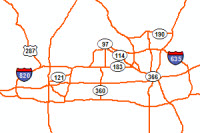

In [14]:
search_result = gis.content.search('title:USA freeway system AND owner:esri', 
                                  item_type = 'Feature Layer', outside_org=True)[0]
search_result

In [15]:
fw_map = gis.map("Atlanta, GA")
fw_map

In [16]:
fw_map.extent

{'spatialReference': {'latestWkid': 4326, 'wkid': 4326},
 'xmax': -84.26510999999996,
 'xmin': -84.51710999999997,
 'ymax': 33.87431000000006,
 'ymin': 33.62231000000006}

In [23]:
freeway_feature_layer = search_result.layers[0]
fw_map.add_layer(freeway_feature_layer, {"renderer":"ClassedSizeRenderer", 
                                         "field_name": "DIST_MILES"})

In [15]:
json.loads(fw_map._js_layer_list)

[{'id': 'graphicsLayer6',
  'normalization': True,
  'refreshInterval': 0,
  'renderer': {'classBreakInfos': [{'classMaxValue': 3.87596,
     'label': '0 to 3.8',
     'symbol': {'color': [226, 119, 40, 255],
      'style': 'esriSLSSolid',
      'type': 'esriSLS',
      'width': 0.75}},
    {'classMaxValue': 8.95041,
     'label': '> 3.8 to 8.9',
     'symbol': {'color': [226, 119, 40, 255],
      'style': 'esriSLSSolid',
      'type': 'esriSLS',
      'width': 3.9375}},
    {'classMaxValue': 20.51156,
     'label': '> 8.9 to 20.5',
     'symbol': {'color': [226, 119, 40, 255],
      'style': 'esriSLSSolid',
      'type': 'esriSLS',
      'width': 7.125}},
    {'classMaxValue': 63.89144,
     'label': '> 20.5 to 63',
     'symbol': {'color': [226, 119, 40, 255],
      'style': 'esriSLSSolid',
      'type': 'esriSLS',
      'width': 10.3125}},
    {'classMaxValue': 2747.27247,
     'label': '> 63 to 2,747',
     'symbol': {'color': [226, 119, 40, 255],
      'style': 'esriSLSSolid',
   

In [25]:
fw_map.save("Freeway ClassedSizeRenderer", "Smartmapping with Python api", ['Automation'])

<Item title:"Freeway ClassedSizeRenderer" type:Web Map owner:arcgis_python>

## Definition queries

In [5]:
fl = FeatureLayer('https://sampleserver6.arcgisonline.com/arcgis/rest/services/Census/MapServer/2')
fl

<FeatureLayer url:"https://sampleserver6.arcgisonline.com/arcgis/rest/services/Census/MapServer/2">

In [6]:
fl.properties.fields

[{
   "name": "OBJECTID",
   "type": "esriFieldTypeOID",
   "alias": "OBJECTID",
   "domain": null
 }, {
   "name": "Shape",
   "type": "esriFieldTypeGeometry",
   "alias": "Shape",
   "domain": null
 }, {
   "name": "NAME",
   "type": "esriFieldTypeString",
   "alias": "NAME",
   "length": 32,
   "domain": null
 }, {
   "name": "STATE_NAME",
   "type": "esriFieldTypeString",
   "alias": "STATE_NAME",
   "length": 25,
   "domain": null
 }, {
   "name": "STATE_FIPS",
   "type": "esriFieldTypeString",
   "alias": "STATE_FIPS",
   "length": 2,
   "domain": null
 }, {
   "name": "CNTY_FIPS",
   "type": "esriFieldTypeString",
   "alias": "CNTY_FIPS",
   "length": 3,
   "domain": null
 }, {
   "name": "FIPS",
   "type": "esriFieldTypeString",
   "alias": "FIPS",
   "length": 5,
   "domain": null
 }, {
   "name": "POP2000",
   "type": "esriFieldTypeInteger",
   "alias": "POP2000",
   "domain": null
 }, {
   "name": "POP2007",
   "type": "esriFieldTypeInteger",
   "alias": "POP2007",
   "domai

In [16]:
df_map = gis.map("Seattle, WA", zoomlevel=6)
df_map

In [8]:
df_map.add_layer(fl, {"definition_expression" : "STATE_NAME ='Washington'",
               "renderer":"ClassedColorRenderer",
               "field_name":"POP2007",
               "opacity":0.7
              })

In [11]:
df_map._webmap._webmapdict['operationalLayers'][0]['layerDefinition'].keys()

dict_keys(['definitionExpression', 'drawingInfo'])

In [10]:
df_map._process_smart_mapping()

In [17]:
df_map.extent

In [12]:
df_map.save("WM with def Expressions 2", "Webmap with definition queries", ['automation'])

<Item title:"WM with def Expressions 2" type:Web Map owner:arcgis_python>